In [67]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [68]:
print("Libraries import successful")

Libraries import successful


In [69]:
# load the dataset 
data = pd.read_csv ("Titanic_dataset.csv")
print("Data loaded successfully")

Data loaded successfully


In [70]:
# create dataframe 
df = pd.DataFrame(data)
df

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C


In [71]:
# separate the input features and the target 
X = df.drop(["Survived","Name"], axis = 1)
X

,PassengerId,Pclass,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,3,male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,3,female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,female,35.0,1,0,113803,53.1000,C123,S
4,5,3,male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...
886,887,2,male,27.0,0,0,211536,13.0000,NaN,S
887,888,1,female,19.0,0,0,112053,30.0000,B42,S
888,889,3,female,NaN,1,2,W./C. 6607,23.4500,NaN,S
889,890,1,male,26.0,0,0,111369,30.0000,C148,C


In [72]:
y = df["Survived"]
y

0      0
1      1
2      1
3      1
4      0
      ..
886    0
887    1
888    0
889    1
890    0
Name: Survived, Length: 891, dtype: int64

In [73]:
# create label encoder
le = LabelEncoder()

In [74]:
# Create a copy of the dataset
X_encoded = df.copy()

# Store encoders for future use
encoders = {}

# Convert all string columns to numeric
for col in X_encoded.columns:
    if X_encoded[col].dtype == 'object':
        le = LabelEncoder()
        X_encoded[col] = le.fit_transform(X_encoded[col].astype(str))
        encoders[col] = le

print(X_encoded.head())

   PassengerId  Survived  Pclass  Name  Sex   Age  SibSp  Parch  Ticket  \
0            1         0       3   108    1  22.0      1      0     523   
1            2         1       1   190    0  38.0      1      0     596   
2            3         1       3   353    0  26.0      0      0     669   
3            4         1       1   272    0  35.0      1      0      49   
4            5         0       3    15    1  35.0      0      0     472   

      Fare  Cabin  Embarked  
0   7.2500    147         2  
1  71.2833     81         0  
2   7.9250    147         2  
3  53.1000     55         2  
4   8.0500    147         2  


In [88]:
X_encoded = X_encoded.drop("Survived", axis=1)
X_encoded

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,3,108,1,22.0,1,0,523,7.2500,147,2
1,2,1,190,0,38.0,1,0,596,71.2833,81,0
2,3,3,353,0,26.0,0,0,669,7.9250,147,2
3,4,1,272,0,35.0,1,0,49,53.1000,55,2
4,5,3,15,1,35.0,0,0,472,8.0500,147,2
...,...,...,...,...,...,...,...,...,...,...,...
886,887,2,548,1,27.0,0,0,101,13.0000,147,2
887,888,1,303,0,19.0,0,0,14,30.0000,30,2
888,889,3,413,0,NaN,1,2,675,23.4500,147,2
889,890,1,81,1,26.0,0,0,8,30.0000,60,0


In [89]:
# separating data from training and testing 
X_train, X_test, y_train, y_test = train_test_split(X_encoded, y, test_size = 0.2, random_state = 42)

In [90]:
# creating the model 
model = RandomForestClassifier (n_estimators = 100, random_state = 42)
print("Model creation successful")

Model creation successful


In [91]:
# training the model 
model.fit (X_train, y_train)

RandomForestClassifier(random_state=42)

In [92]:
# predicting values 
y_pred = model.predict (X_test)

In [93]:
accuracy = accuracy_score (y_test, y_pred)
print("Accuracy is: ", accuracy)

Accuracy is:  0.8324022346368715


In [94]:
print(confusion_matrix(y_test, y_pred))

[[94 11]
 [19 55]]


In [95]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.83      0.90      0.86       105
           1       0.83      0.74      0.79        74

    accuracy                           0.83       179
   macro avg       0.83      0.82      0.82       179
weighted avg       0.83      0.83      0.83       179



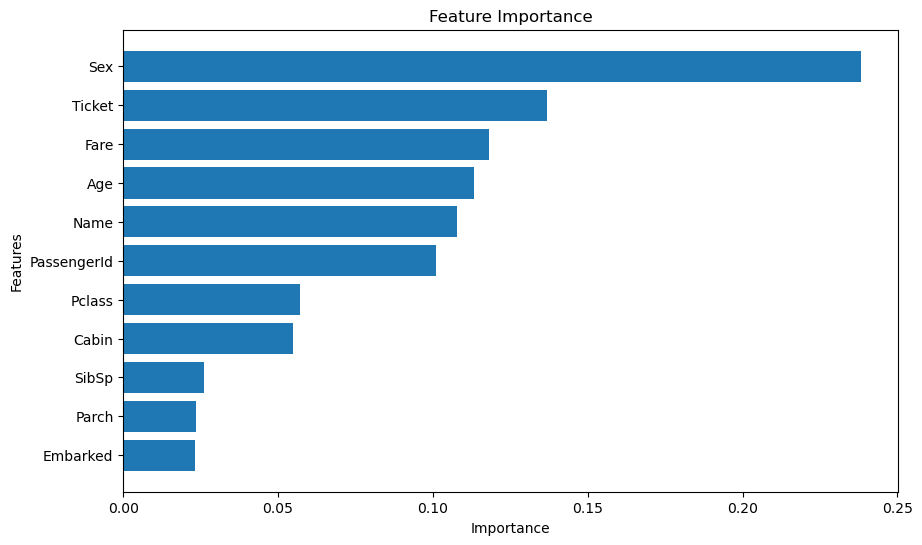

In [96]:

importance = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': model.feature_importances_
})

importance = importance.sort_values(
    by='Importance',
    ascending=False
)

plt.figure(figsize=(10,6))
plt.barh(
    importance['Feature'],
    importance['Importance']
)

plt.xlabel("Importance")
plt.ylabel("Features")
plt.title("Feature Importance")
plt.gca().invert_yaxis()
plt.show()

In [97]:
np.random.seed(42)

names = [
    "John Smith", "Mary Johnson", "James Brown", "Patricia Davis",
    "Robert Wilson", "Jennifer Moore", "Michael Taylor", "Linda Anderson"
]

sexes = ["male", "female"]
embarked_ports = ["S", "C", "Q"]

data = {
    "PassengerId": range(1, 51),
    "Survived": np.random.randint(0, 2, 50),
    "Pclass": np.random.randint(1, 4, 50),
    "Name": np.random.choice(names, 50),
    "Sex": np.random.choice(sexes, 50),
    "Age": np.random.randint(1, 80, 50),
    "SibSp": np.random.randint(0, 5, 50),
    "Parch": np.random.randint(0, 4, 50),
    "Ticket": [f"TKT{1000+i}" for i in range(50)],
    "Fare": np.round(np.random.uniform(5, 100, 50), 2),
    "Cabin": [f"C{i}" for i in range(1, 51)],
    "Embarked": np.random.choice(embarked_ports, 50)
}

df_sample = pd.DataFrame(data)

print(df_sample)

    PassengerId  Survived  Pclass            Name     Sex  Age  SibSp  Parch  \
0             1         0       3  Linda Anderson  female   59      1      2   
1             2         1       2   Robert Wilson    male   28      3      2   
2             3         0       3    Mary Johnson    male   66      2      3   
3             4         0       3  Michael Taylor  female   42      2      3   
4             5         0       1   Robert Wilson  female   45      0      2   
5             6         1       3  Linda Anderson  female   62      4      3   
6             7         0       1    Mary Johnson    male   57      3      3   
7             8         0       3      John Smith    male    6      1      1   
8             9         0       3  Patricia Davis    male   28      2      3   
9            10         1       1  Patricia Davis    male   28      0      0   
10           11         0       1  Patricia Davis    male   44      0      3   
11           12         0       3   Robe

In [116]:
y_sample = df_sample["Survived"]
y_sample

0     0
1     1
2     0
3     0
4     0
5     1
6     0
7     0
8     0
9     1
10    0
11    0
12    0
13    0
14    1
15    0
16    1
17    1
18    1
19    0
20    1
21    0
22    1
23    1
24    1
25    1
26    1
27    1
28    1
29    1
30    0
31    0
32    1
33    1
34    1
35    0
36    1
37    0
38    0
39    0
40    0
41    0
42    1
43    1
44    1
45    1
46    1
47    0
48    1
49    1
Name: Survived, dtype: int32

In [106]:
# Create a copy of the dataset
X_sample_encoded = X_sample.copy()

# Store encoders for future use
encoders = {}

# Convert all string columns to numeric
for col in X_sample_encoded.columns:
    if X_sample_encoded[col].dtype == 'object':
        le = LabelEncoder()
        X_sample_encoded[col] = le.fit_transform(X_sample_encoded[col].astype(str))
        encoders[col] = le

print(X_sample_encoded.head())

   PassengerId  Pclass  Name  Sex  Age  SibSp  Parch  Ticket   Fare  Cabin  \
0            1       3     3    0   59      1      2       0  67.47      0   
1            2       2     7    1   28      3      2       1  58.99     11   
2            3       3     4    1   66      2      3       2  13.90     22   
3            4       3     5    0   42      2      3       3  39.93     33   
4            5       1     7    0   45      0      2       4  30.19     44   

   Embarked  
0         1  
1         0  
2         1  
3         0  
4         2  


In [110]:
X_sample_encoded

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,3,3,0,59,1,2,0,67.47,0,1
1,2,2,7,1,28,3,2,1,58.99,11,0
2,3,3,4,1,66,2,3,2,13.90,22,1
3,4,3,5,0,42,2,3,3,39.93,33,0
4,5,1,7,0,45,0,2,4,30.19,44,2
5,6,3,3,0,62,4,3,5,28.18,46,2
6,7,1,4,1,57,3,3,6,97.44,47,0
7,8,3,2,1,6,1,1,7,42.34,48,1
8,9,3,6,1,28,2,3,8,89.74,49,2
9,10,1,6,1,28,0,0,9,64.96,1,2


In [112]:
y_pred_sample = model.predict(X_sample_encoded)

In [121]:
accuracy_sample = accuracy_score (y_sample, y_pred_sample)
print("Accuracy on test data is:", accuracy_sample)

Accuracy on test data is: 0.4


In [123]:
print(confusion_matrix(y_sample, y_pred_sample))

[[ 5 18]
 [12 15]]


In [122]:
print(classification_report(y_sample, y_pred_sample))

              precision    recall  f1-score   support

           0       0.29      0.22      0.25        23
           1       0.45      0.56      0.50        27

    accuracy                           0.40        50
   macro avg       0.37      0.39      0.38        50
weighted avg       0.38      0.40      0.39        50

